# **Introduction of the dataset**
The dataset used in this analysis belongs to an United States Top 50 Playlist Performance and Song Popularity Trend Analysis analysis. It consist of tablle that capture diffrent columns such as song, artist,populartity.

**The main objective of the dataset is to analyze:**



*   Analyze ranking stability and volatility
*   Measure song longevity and popularity trends

*   Identify dominant artists and songs
*   Compare explicit vs non-explicit content

*   Compare singles vs album tracks
*   Study duration and album size impact

*   Develop key performance indicators (KPIs)




In [1]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Load the dataset

df = pd.read_csv('/content/Atlantic_United_States.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print(df.shape)

(22994, 10)


In [4]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1.0,Ella Baila Sola,Eslabon Armado,89.0,165671.0,album,16.0,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2.0,Last Night,Morgan Wallen,89.0,163854.0,album,36.0,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3.0,All My Life (feat. J. Cole),Lil Durk & J. Cole,84.0,223878.0,single,1.0,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4.0,un x100to,Grupo Frontera & Bad Bunny,99.0,194563.0,single,1.0,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5.0,Kill Bill,SZA,94.0,153946.0,album,23.0,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


# **Data Preprocessing**

**Data Inspection**

In [5]:
#Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22994 entries, 0 to 22993
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             22994 non-null  object 
 1   position         22993 non-null  float64
 2   song             22993 non-null  object 
 3   artist           22993 non-null  object 
 4   popularity       22993 non-null  float64
 5   duration_ms      22993 non-null  float64
 6   album_type       22993 non-null  object 
 7   total_tracks     22993 non-null  float64
 8   is_explicit      22993 non-null  object 
 9   album_cover_url  22993 non-null  object 
dtypes: float64(4), object(6)
memory usage: 1.8+ MB


In [6]:
df.columns

Index(['date', 'position', 'song', 'artist', 'popularity', 'duration_ms',
       'album_type', 'total_tracks', 'is_explicit', 'album_cover_url'],
      dtype='object')

In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)


Missing Values:
date               0
position           1
song               1
artist             1
popularity         1
duration_ms        1
album_type         1
total_tracks       1
is_explicit        1
album_cover_url    1
dtype: int64


In [8]:
# Check duplicate song-date entries

duplicates = df.duplicated(subset=['date', 'song', 'artist'], keep=False)

print("Number of duplicate song-date entries:", duplicates.sum())


Number of duplicate song-date entries: 96


In [9]:

# Investigate dates containing duplicate entries

duplicate_dates = df.loc[duplicates, 'date'].unique()

print("Dates containing duplicates:")
print(duplicate_dates)

print("\nNumber of rows for these dates:")
print(df[df['date'].isin(duplicate_dates)].groupby('date').size())


Dates containing duplicates:
['01-03-2025']

Number of rows for these dates:
date
01-03-2025    100
dtype: int64


In [10]:

# Remove duplicate playlist entries

df = df.drop_duplicates(
    subset=['date', 'position'],
    keep='first'
).reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate date-position entries:",
      df.duplicated(subset=['date', 'position']).sum())

Dataset shape after removing duplicates: (22944, 10)
Remaining duplicate date-position entries: 0


In [11]:
# Validate playlist rank range

print("Minimum rank:", df['position'].min())
print("Maximum rank:", df['position'].max())

invalid_ranks = df[(df['position'] < 1) | (df['position'] > 50)]

print("Number of invalid ranks:", len(invalid_ranks))

Minimum rank: 1.0
Maximum rank: 50.0
Number of invalid ranks: 0


In [12]:
# Convert date column to datetime

df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

print("Date data type:", df['date'].dtype)
print("Earliest date:", df['date'].min())
print("Latest date:", df['date'].max())

ValueError: time data "23-08-" doesn't match format "%d-%m-%Y", at position 459. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [13]:
# Validate number of playlist entries per day

daily_counts = df.groupby('date').size()

print("Minimum entries per day:", daily_counts.min())
print("Maximum entries per day:", daily_counts.max())

invalid_days = daily_counts[daily_counts != 50]

print("Number of days not having exactly 50 entries:", len(invalid_days))

invalid_days.head()

Minimum entries per day: 1
Maximum entries per day: 50
Number of days not having exactly 50 entries: 2


,0
date,
23-08-,1
23-08-2025,43


In [14]:

# Standardize artist name formatting

df['artist'] = df['artist'].str.strip()
df['artist'] = df['artist'].str.replace(r'\s+', ' ', regex=True)

print("Artist names standardized successfully!")
print("Number of unique artists:", df['artist'].nunique())

df['artist'].head(10)

Artist names standardized successfully!
Number of unique artists: 273


,artist
0,Eslabon Armado
1,Morgan Wallen
2,Lil Durk & J. Cole
3,Grupo Frontera & Bad Bunny
4,SZA
5,"Tyler, The Creator"
6,FIFTY FIFTY
7,Yng Lvcas & Peso Pluma
8,PinkPantheress & Ice Spice
9,Lil Mabu


# **Feature Engineering**

In [15]:
# Convert song duration from milliseconds to minutes

df['duration_min'] = df['duration_ms'] / 60000

print("Duration in minutes created successfully!")

df[['song', 'duration_ms', 'duration_min']].head()


Duration in minutes created successfully!


,song,duration_ms,duration_min
0,Ella Baila Sola,165671.0,2.761183
1,Last Night,163854.0,2.730900
2,All My Life (feat. J. Cole),223878.0,3.731300
3,un x100to,194563.0,3.242717
4,Kill Bill,153946.0,2.565767


In [16]:
# Calculate Days on Chart for each song

days_on_chart = (
    df.groupby(['song', 'artist'])['date']
    .nunique()
    .reset_index(name='days_on_chart')
)

print("Days on Chart calculated successfully!")
print("Total unique songs:", len(days_on_chart))

days_on_chart.sort_values(
    'days_on_chart',
    ascending=False
).head(10)


Days on Chart calculated successfully!
Total unique songs: 861


,song,artist,days_on_chart
627,Something in the Orange,Zach Bryan,446
390,Last Night,Morgan Wallen,444
158,Cruel Summer,Taylor Swift,388
333,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,356
593,See You Again (feat. Kali Uchis),"Tyler, The Creator",348
639,Stick Season,Noah Kahan,322
703,Thinkin’ Bout Me,Morgan Wallen,320
784,You Proof,Morgan Wallen,302
618,Snooze,SZA,282
469,No Role Modelz,J. Cole,272


In [17]:
# Calculate Average Rank and Best Rank

song_rank_metrics = (
    df.groupby(['song', 'artist'])
    .agg(
        average_rank=('position', 'mean'),
        best_rank=('position', 'min')
    )
    .reset_index()
)

song_rank_metrics['average_rank'] = song_rank_metrics['average_rank'].round(2)

print("Rank metrics calculated successfully!")

song_rank_metrics.sort_values('average_rank').head(10)


Rank metrics calculated successfully!


,song,artist,average_rank,best_rank
415,MELTDOWN,Travis Scott,1.00,1.0
324,I Had Some Help (Feat. Morgan Wallen),Post Malone,2.14,1.0
223,FE!N,Travis Scott,2.33,2.0
474,Not Like Us,Kendrick Lamar,2.81,1.0
522,Please Please Please,Sabrina Carpenter,3.57,1.0
325,I Had Some Help (Feat. Morgan Wallen),Post Malone & Morgan Wallen,3.91,1.0
600,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto & BTS,4.00,4.0
509,Parade on Cleveland (feat. Drake),Young Thug,4.00,4.0
71,BIRDS OF A FEATHER,Billie Eilish,4.46,2.0
765,Who,Jimin,4.48,1.0


In [18]:
# Calculate Rank Volatility Index

rank_volatility = (
    df.groupby(['song', 'artist'])['position']
    .std()
    .reset_index(name='rank_volatility')
)

rank_volatility['rank_volatility'] = rank_volatility['rank_volatility'].round(2)

print("Rank Volatility Index calculated successfully!")

rank_volatility.sort_values(
    'rank_volatility',
    ascending=False
).head(10)

Rank Volatility Index calculated successfully!


,song,artist,rank_volatility
159,Cruel Summer - Live from TS | The Eras Tour,Taylor Swift,25.46
641,Stories About My Brother,Drake,24.75
230,FUK SUMN,Kanye West & Ty Dolla $ign,23.37
54,As Good As I Once Was,Toby Keith,22.63
771,Wildflower and Barley (feat. Allison Russell),Hozier,22.63
731,VOU 787,Bad Bunny,21.94
705,This Is Halloween,Various Artists,21.46
640,Stickz N Stonez,J. Cole,21.21
707,Thriller,Michael Jackson,21.03
266,GRACIAS POR NADA,Bad Bunny,20.78


In [19]:
# Calculate 7-day Popularity Trend Score

df = df.sort_values(['song', 'artist', 'date'])

df['popularity_trend'] = (
    df.groupby(['song', 'artist'])['popularity']
      .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df['popularity_trend'] = df['popularity_trend'].round(2)

print("Popularity Trend Score calculated successfully!")

df[['date', 'song', 'artist', 'popularity', 'popularity_trend']].head(10)

Popularity Trend Score calculated successfully!


,date,song,artist,popularity,popularity_trend
8354,01-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,88.0,88.00
8402,02-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,89.0,88.50
8452,03-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,90.0,89.00
8502,04-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,90.0,89.25
8552,05-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91.0,89.60
8603,06-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91.0,89.83
8656,07-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91.0,90.00
8707,08-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91.0,90.43
8760,09-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91.0,90.71
8810,10-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,91.0,90.86


In [20]:
# Combine song-level KPI metrics

song_kpis = days_on_chart.merge(
    song_rank_metrics,
    on=['song', 'artist']
)

song_kpis = song_kpis.merge(
    rank_volatility,
    on=['song', 'artist']
)

# Songs appearing only once have no standard deviation
song_kpis['rank_volatility'] = song_kpis['rank_volatility'].fillna(0)

print("Song-level KPI table created successfully!")
print("Shape:", song_kpis.shape)

song_kpis.head(10)

Song-level KPI table created successfully!
Shape: (861, 6)


,song,artist,days_on_chart,average_rank,best_rank,rank_volatility
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,26,15.50,3.0,12.13
1,(There's No Place Like) Home for the Holidays ...,Perry Como,2,45.00,45.0,0.00
2,16 CARRIAGES,Beyoncé,10,26.00,16.0,10.64
3,28,Zach Bryan,47,18.53,10.0,9.47
4,3001,J. Cole,1,32.00,32.0,0.00
5,360,Charli xcx,35,31.20,19.0,8.22
6,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,12,26.33,9.0,18.43
7,500lbs,Lil Tecca,186,24.83,12.0,10.01
8,7 Minute Drill,J. Cole,7,16.57,3.0,11.67
9,7969 Santa,Drake,7,15.00,9.0,4.86


In [21]:

# Add popularity metrics to song KPI table

popularity_metrics = (
    df.groupby(['song', 'artist'])
    .agg(
        average_popularity=('popularity', 'mean'),
        popularity_trend_score=('popularity_trend', 'last')
    )
    .reset_index()
)

popularity_metrics['average_popularity'] = (
    popularity_metrics['average_popularity'].round(2)
)

song_kpis = song_kpis.merge(
    popularity_metrics,
    on=['song', 'artist']
)

print("Popularity metrics added successfully!")

song_kpis.head(10)

Popularity metrics added successfully!


,song,artist,days_on_chart,average_rank,best_rank,rank_volatility,average_popularity,popularity_trend_score
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,26,15.50,3.0,12.13,86.77,76.29
1,(There's No Place Like) Home for the Holidays ...,Perry Como,2,45.00,45.0,0.00,70.00,70.00
2,16 CARRIAGES,Beyoncé,10,26.00,16.0,10.64,64.50,68.29
3,28,Zach Bryan,47,18.53,10.0,9.47,84.26,86.14
4,3001,J. Cole,1,32.00,32.0,0.00,68.00,68.00
5,360,Charli xcx,35,31.20,19.0,8.22,87.57,86.71
6,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,12,26.33,9.0,18.43,66.25,68.86
7,500lbs,Lil Tecca,186,24.83,12.0,10.01,83.39,81.71
8,7 Minute Drill,J. Cole,7,16.57,3.0,11.67,78.86,78.86
9,7969 Santa,Drake,7,15.00,9.0,4.86,67.14,67.14


# **Playlist Ranking Analysis**

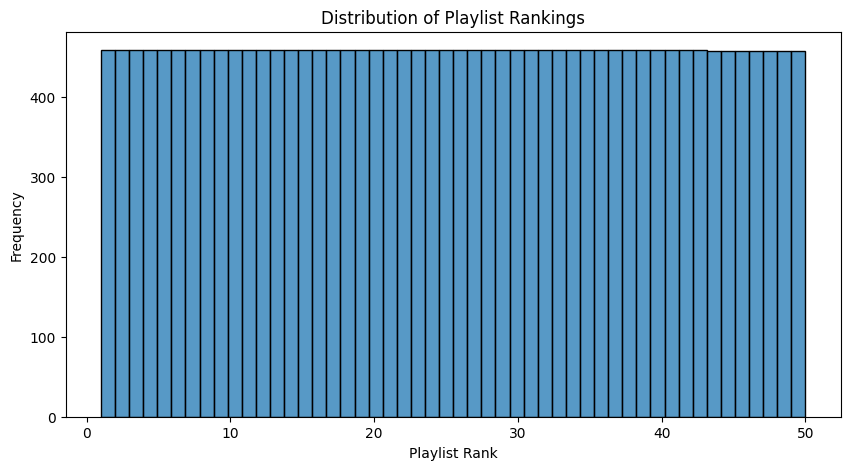

In [22]:

# Daily rank distribution

plt.figure(figsize=(10, 5))

sns.histplot(df['position'], bins=50)

plt.title('Distribution of Playlist Rankings')
plt.xlabel('Playlist Rank')
plt.ylabel('Frequency')

plt.show()

**Analysis:**

Playlist ranks are uniformly distributed from 1 to 50 because each daily snapshot contains exactly one song at every rank, confirming consistent Top 50 coverage across the datase


In [23]:

# Calculate rank movement between consecutive appearances

df = df.sort_values(['song', 'artist', 'date'])

df['previous_rank'] = (
    df.groupby(['song', 'artist'])['position'].shift(1)
)

df['rank_movement'] = df['previous_rank'] - df['position']

print("Rank movement calculated successfully!")

df[['date', 'song', 'artist', 'position',
    'previous_rank', 'rank_movement']].dropna().head(10)

Rank movement calculated successfully!


,date,song,artist,position,previous_rank,rank_movement
8402,02-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,5.0,2.0
8452,03-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,3.0,0.0
8502,04-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,3.0,0.0
8552,05-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3.0,3.0,0.0
8603,06-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,4.0,3.0,-1.0
8656,07-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,7.0,4.0,-3.0
8707,08-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,8.0,7.0,-1.0
8760,09-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,11.0,8.0,-3.0
8810,10-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,11.0,11.0,0.0
8867,11-11-2024,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,18.0,11.0,-7.0


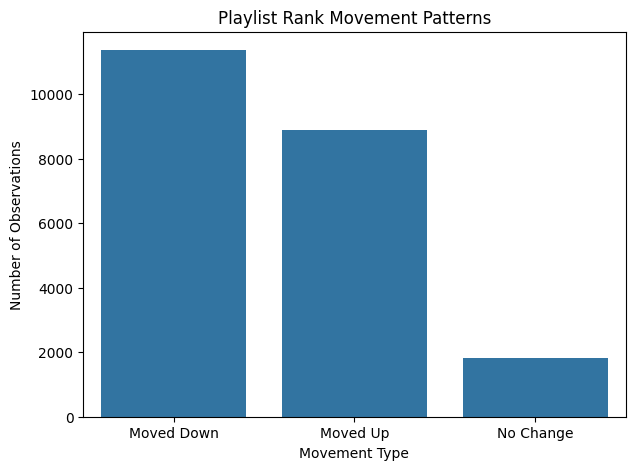

movement_type
Moved Down    11374
Moved Up       8889
No Change      1819
Name: count, dtype: int64


In [24]:
# Classify rank movements

df['movement_type'] = np.where(
    df['rank_movement'] > 0, 'Moved Up',
    np.where(df['rank_movement'] < 0, 'Moved Down', 'No Change')
)

movement_counts = df[df['previous_rank'].notna()]['movement_type'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=movement_counts.index, y=movement_counts.values)

plt.title('Playlist Rank Movement Patterns')
plt.xlabel('Movement Type')
plt.ylabel('Number of Observations')

plt.show()

print(movement_counts)

**Analysis:**

Songs moved down the chart more frequently than they moved up, while a large number of rankings remained stable between consecutive appearances.

In [25]:
# Analyze song entry and exit behavior

song_entry_exit = (
    df.groupby(['song', 'artist'])
    .agg(
        entry_date=('date', 'min'),
        exit_date=('date', 'max'),
        entry_rank=('position', 'first'),
        exit_rank=('position', 'last')
    )
    .reset_index()
)

print("Entry and exit behavior calculated successfully!")
print("Total songs:", len(song_entry_exit))

song_entry_exit.head(10)


Entry and exit behavior calculated successfully!
Total songs: 861


,song,artist,entry_date,exit_date,entry_rank,exit_rank
0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,01-11-2024,31-10-2024,5.0,3.0
1,(There's No Place Like) Home for the Holidays ...,Perry Como,26-12-2024,27-12-2024,45.0,45.0
2,16 CARRIAGES,Beyoncé,01-04-2025,31-03-2025,17.0,16.0
3,28,Zach Bryan,01-08-2025,31-07-2025,15.0,12.0
4,3001,J. Cole,07-04-2025,07-04-2025,32.0,32.0
5,360,Charli xcx,01-08-2025,31-07-2025,23.0,22.0
6,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,01-10-2024,30-09-2024,9.0,9.0
7,500lbs,Lil Tecca,01-01-2025,31-12-2024,17.0,18.0
8,7 Minute Drill,J. Cole,07-04-2025,13-04-2025,3.0,33.0
9,7969 Santa,Drake,07-10-2024,13-10-2024,9.0,23.0


In [26]:
# Keep rank movement only for consecutive-day appearances

df['previous_date'] = (
    df.groupby(['song', 'artist'])['date'].shift(1)
)

df['day_gap'] = (df['date'] - df['previous_date']).dt.days

df['daily_rank_movement'] = np.where(
    df['day_gap'] == 1,
    df['previous_rank'] - df['position'],
    np.nan
)

print("Daily rank movement corrected successfully!")

df[['date', 'song', 'position', 'previous_rank',
    'day_gap', 'daily_rank_movement']].dropna().head(10)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [27]:
# Fast risers and decliners using consecutive-day movements only

daily_movement_summary = (
    df.dropna(subset=['daily_rank_movement'])
    .groupby(['song', 'artist'])
    .agg(
        average_daily_movement=('daily_rank_movement', 'mean'),
        biggest_daily_rise=('daily_rank_movement', 'max'),
        biggest_daily_drop=('daily_rank_movement', 'min')
    )
    .reset_index()
    .round(2)
)

print("Top 10 Fast Risers:")
display(
    daily_movement_summary
    .sort_values('biggest_daily_rise', ascending=False)
    .head(10)
)

print("\nTop 10 Biggest Decliners:")
display(
    daily_movement_summary
    .sort_values('biggest_daily_drop')
    .head(10)
)

KeyError: ['daily_rank_movement']

# **Song Level Performance Analysis**

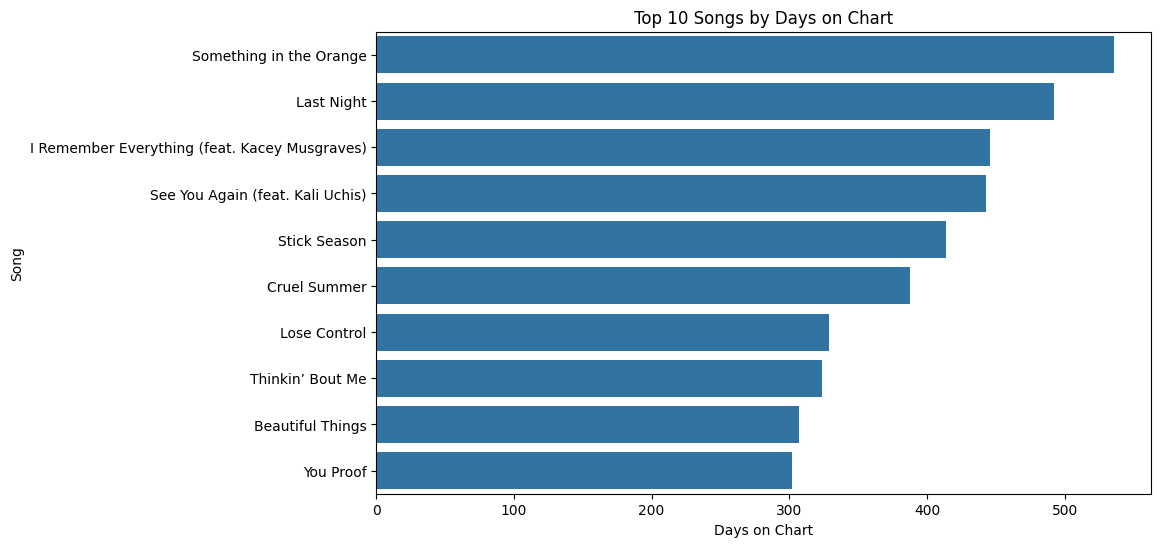

,song,artist,days_on_chart
696,Something in the Orange,Zach Bryan,536
427,Last Night,Morgan Wallen,492
364,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,446
659,See You Again (feat. Kali Uchis),"Tyler, The Creator",443
709,Stick Season,Noah Kahan,414
170,Cruel Summer,Taylor Swift,388
444,Lose Control,Teddy Swims,329
790,Thinkin’ Bout Me,Morgan Wallen,324
99,Beautiful Things,Benson Boone,307
884,You Proof,Morgan Wallen,302


In [ ]:
# Top 10 songs with longest playlist presence

longest_presence = (
    song_kpis
    .sort_values('days_on_chart', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=longest_presence,
    x='days_on_chart',
    y='song'
)

plt.title('Top 10 Songs by Days on Chart')
plt.xlabel('Days on Chart')
plt.ylabel('Song')

plt.show()

longest_presence[['song', 'artist', 'days_on_chart']]



**Analysis:**

“Something in the Orange” shows the strongest playlist longevity with 536 days on chart, followed by “Last Night” with 492 days. This indicates sustained listener interest and long-term playlist relevance.

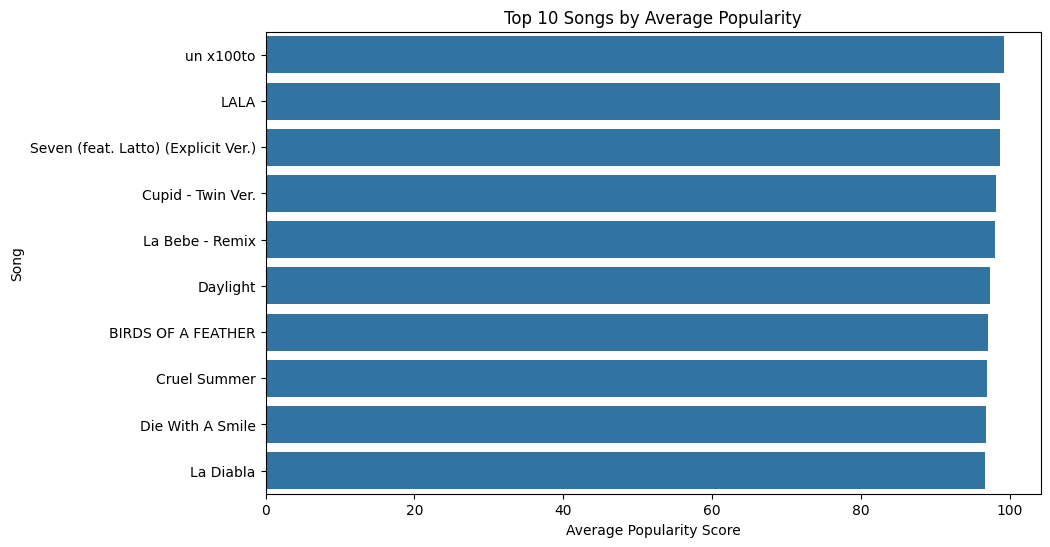

,song,artist,average_popularity,days_on_chart
968,un x100to,Grupo Frontera & Bad Bunny,99.20,79
411,LALA,Myke Towers,98.69,49
665,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,98.65,81
174,Cupid - Twin Ver.,FIFTY FIFTY,98.20,71
421,La Bebe - Remix,Yng Lvcas & Peso Pluma,98.01,113
191,Daylight,David Kushner,97.40,55
78,BIRDS OF A FEATHER,Billie Eilish,97.16,191
170,Cruel Summer,Taylor Swift,97.01,388
208,Die With A Smile,Lady Gaga & Bruno Mars,96.81,103
422,La Diabla,Xavi,96.67,104


In [ ]:
# Top songs by average popularity
# Minimum 7 days on chart for a meaningful comparison

top_popular_songs = (
    song_kpis[song_kpis['days_on_chart'] >= 7]
    .sort_values('average_popularity', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_popular_songs,
    x='average_popularity',
    y='song'
)

plt.title('Top 10 Songs by Average Popularity')
plt.xlabel('Average Popularity Score')
plt.ylabel('Song')

plt.show()

top_popular_songs[
    ['song', 'artist', 'average_popularity', 'days_on_chart']
]

**Analysis:**

“un x100to” has the highest average popularity score (99.20), while “Cruel Summer” combines very high popularity (97.01) with exceptional longevity of 388 chart days.

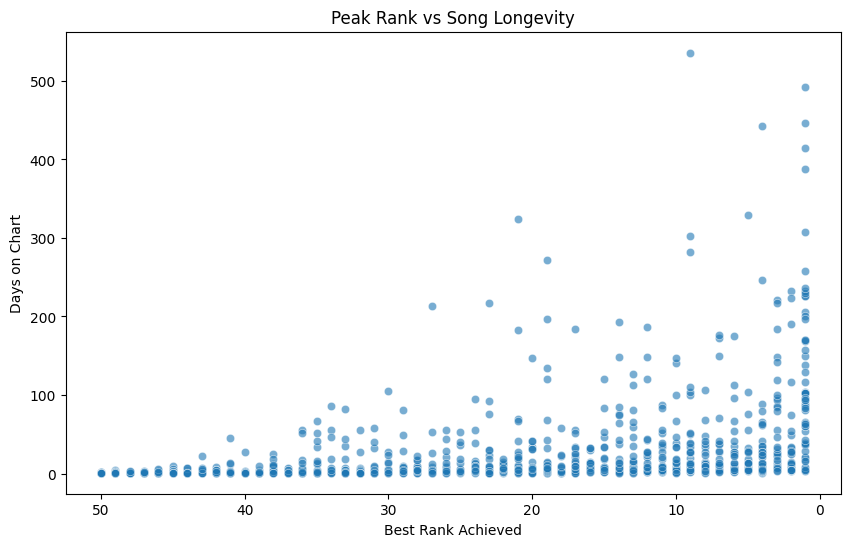

Correlation between best rank and days on chart: -0.342


In [ ]:
# Compare best rank with chart longevity

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=song_kpis,
    x='best_rank',
    y='days_on_chart',
    alpha=0.6
)

plt.title('Peak Rank vs Song Longevity')
plt.xlabel('Best Rank Achieved')
plt.ylabel('Days on Chart')

plt.gca().invert_xaxis()

plt.show()

correlation = song_kpis['best_rank'].corr(song_kpis['days_on_chart'])

print("Correlation between best rank and days on chart:",
      round(correlation, 3))

**Analysis:**

Peak rank and chart longevity show a moderate relationship (r = -0.342). Songs reaching stronger peak positions generally remain on the playlist longer, but peak performance alone does not guarantee sustained chart presence.

# **Artist Performance Analysis**

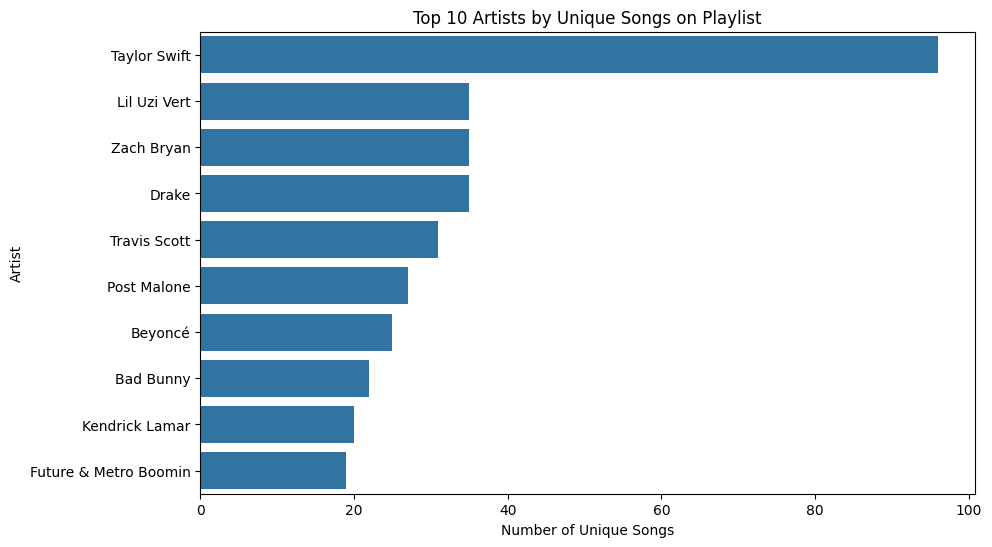

,artist,unique_songs
0,Taylor Swift,96
1,Lil Uzi Vert,35
2,Zach Bryan,35
3,Drake,35
4,Travis Scott,31
5,Post Malone,27
6,Beyoncé,25
7,Bad Bunny,22
8,Kendrick Lamar,20
9,Future & Metro Boomin,19


In [ ]:
# Top artists by number of unique songs

artist_unique_songs = (
    df.groupby('artist')['song']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='unique_songs')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=artist_unique_songs,
    x='unique_songs',
    y='artist'
)

plt.title('Top 10 Artists by Unique Songs on Playlist')
plt.xlabel('Number of Unique Songs')
plt.ylabel('Artist')

plt.show()

artist_unique_songs

**Analysis:**

Taylor Swift dominates playlist breadth with 96 unique songs, substantially more than any other artist, indicating exceptionally strong and repeated playlist representation.

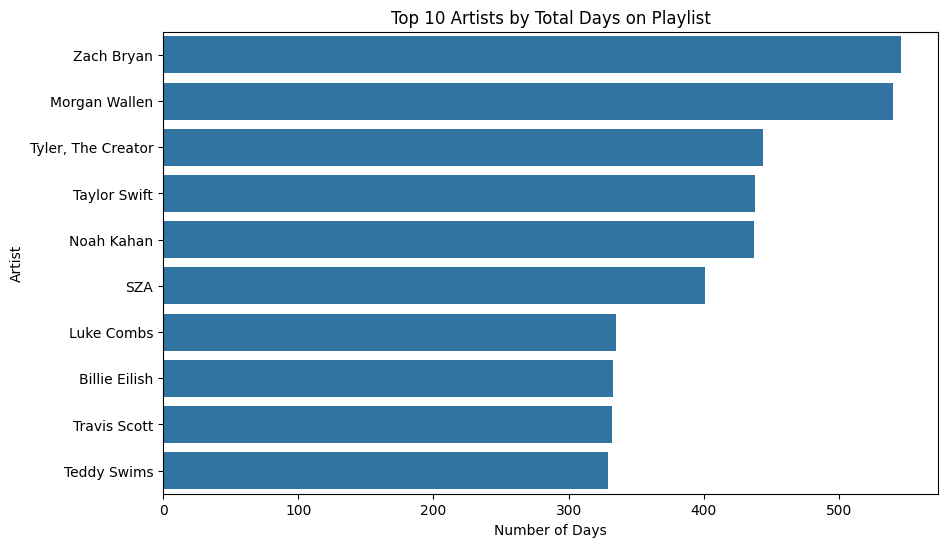

,artist,total_days
0,Zach Bryan,546
1,Morgan Wallen,540
2,"Tyler, The Creator",444
3,Taylor Swift,438
4,Noah Kahan,437
5,SZA,401
6,Luke Combs,335
7,Billie Eilish,333
8,Travis Scott,332
9,Teddy Swims,329


In [ ]:

# Calculate total unique days each artist appears

artist_days = (
    df.groupby('artist')['date']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='total_days')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=artist_days,
    x='total_days',
    y='artist'
)

plt.title('Top 10 Artists by Total Days on Playlist')
plt.xlabel('Number of Days')
plt.ylabel('Artist')

plt.show()

artist_days

**Analysis:**

Zach Bryan leads in long-term playlist presence with 546 days, closely followed by Morgan Wallen with 540 days, showing strong and sustained artist visibility.

In [ ]:

# Calculate Artist Dominance Index

artist_dominance = (
    df.groupby('artist')
    .size()
    .reset_index(name='total_appearances')
)

artist_dominance['dominance_index'] = (
    artist_dominance['total_appearances'] / len(df) * 100
).round(2)

artist_dominance = (
    artist_dominance
    .sort_values('dominance_index', ascending=False)
    .head(10)
)

print("Top 10 Artists by Dominance Index:")
artist_dominance


Top 10 Artists by Dominance Index:


,artist,total_appearances,dominance_index
242,Taylor Swift,2015,7.26
286,Zach Bryan,1857,6.69
177,Morgan Wallen,1669,6.01
229,Sabrina Carpenter,967,3.48
65,Drake,841,3.03
40,Chappell Roan,794,2.86
266,Travis Scott,762,2.75
22,Billie Eilish,729,2.63
273,"Tyler, The Creator",705,2.54
227,SZA,648,2.34


**Analysis:**

Taylor Swift has the highest Artist Dominance Index at 7.26%, followed by Zach Bryan (6.69%) and Morgan Wallen (6.01%), indicating the strongest overall playlist presence.

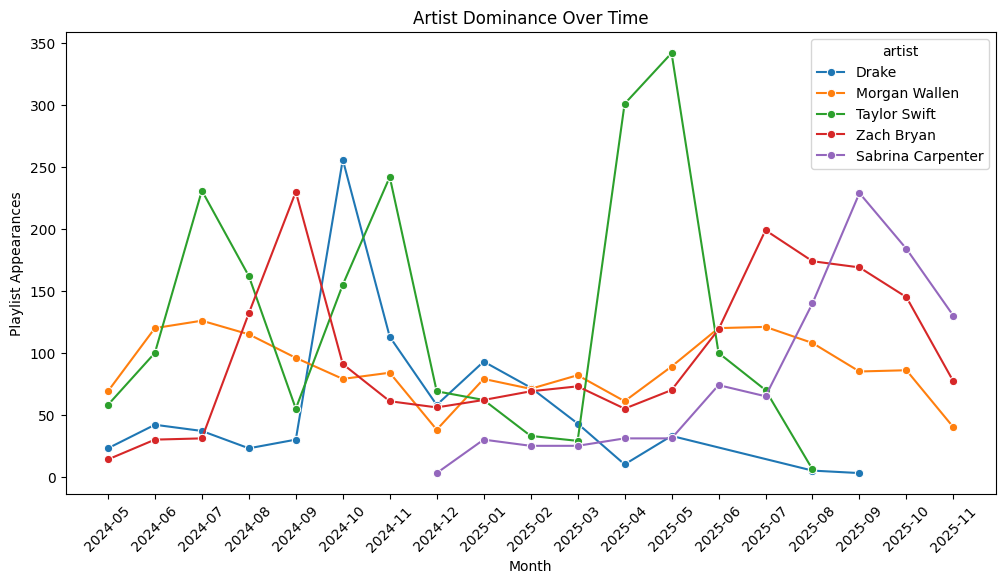

In [ ]:
# Analyze artist dominance over time

top_artists = artist_dominance['artist'].head(5).tolist()

artist_monthly = (
    df[df['artist'].isin(top_artists)]
    .assign(month=df['date'].dt.to_period('M').astype(str))
    .groupby(['month', 'artist'])
    .size()
    .reset_index(name='appearances')
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=artist_monthly,
    x='month',
    y='appearances',
    hue='artist',
    marker='o'
)

plt.title('Artist Dominance Over Time')
plt.xlabel('Month')
plt.ylabel('Playlist Appearances')
plt.xticks(rotation=45)

plt.show()

**Analysis:**

Artist dominance changes considerably over time, with Taylor Swift showing the strongest monthly peaks, while Zach Bryan, Drake, Morgan Wallen, and Sabrina Carpenter lead during different periods

# **Popularity Score Analytics**

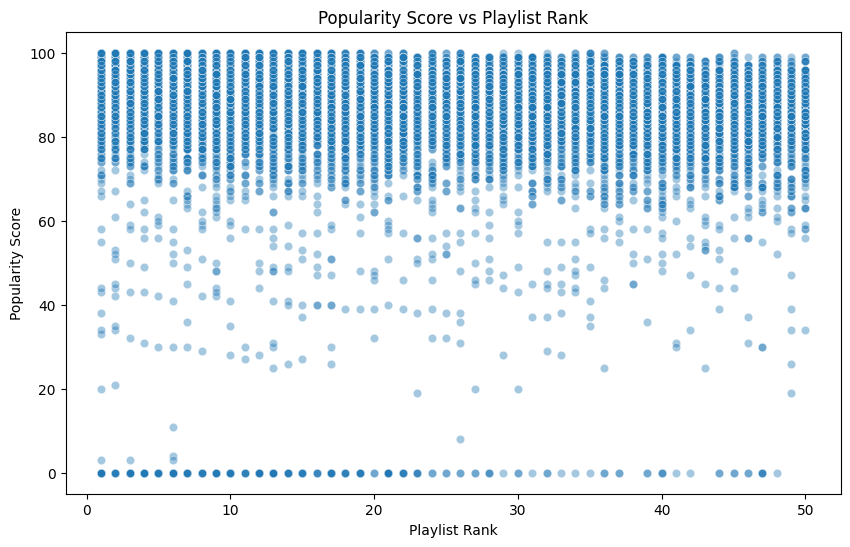

Correlation between playlist rank and popularity: -0.094


In [ ]:
# Analyze relationship between popularity and playlist rank

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='position',
    y='popularity',
    alpha=0.4
)

plt.title('Popularity Score vs Playlist Rank')
plt.xlabel('Playlist Rank')
plt.ylabel('Popularity Score')

plt.show()

pop_rank_corr = df['position'].corr(df['popularity'])

print("Correlation between playlist rank and popularity:",
      round(pop_rank_corr, 3))

**Analysis:**

Popularity and playlist rank show a very weak negative correlation (r = -0.094), indicating that popularity score alone does not strongly explain a song's playlist position.

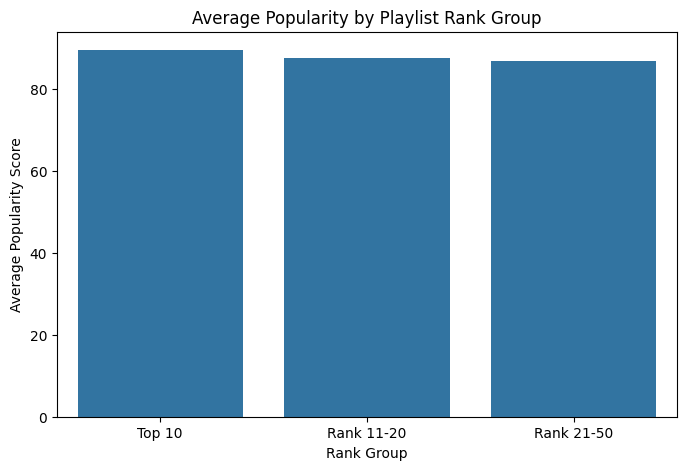

,rank_group,popularity
0,Top 10,89.61
1,Rank 11-20,87.59
2,Rank 21-50,87.03


In [ ]:
# Compare popularity across playlist rank groups

df['rank_group'] = pd.cut(
    df['position'],
    bins=[0, 10, 20, 50],
    labels=['Top 10', 'Rank 11-20', 'Rank 21-50']
)

rank_popularity = (
    df.groupby('rank_group', observed=True)['popularity']
    .mean()
    .round(2)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rank_popularity,
    x='rank_group',
    y='popularity'
)

plt.title('Average Popularity by Playlist Rank Group')
plt.xlabel('Rank Group')
plt.ylabel('Average Popularity Score')

plt.show()

rank_popularity

**Analysis:**

Top 10 songs have the highest average popularity (89.61), compared with 87.59 for ranks 11–20 and 87.03 for ranks 21–50, showing only a modest popularity advantage for higher-ranked songs

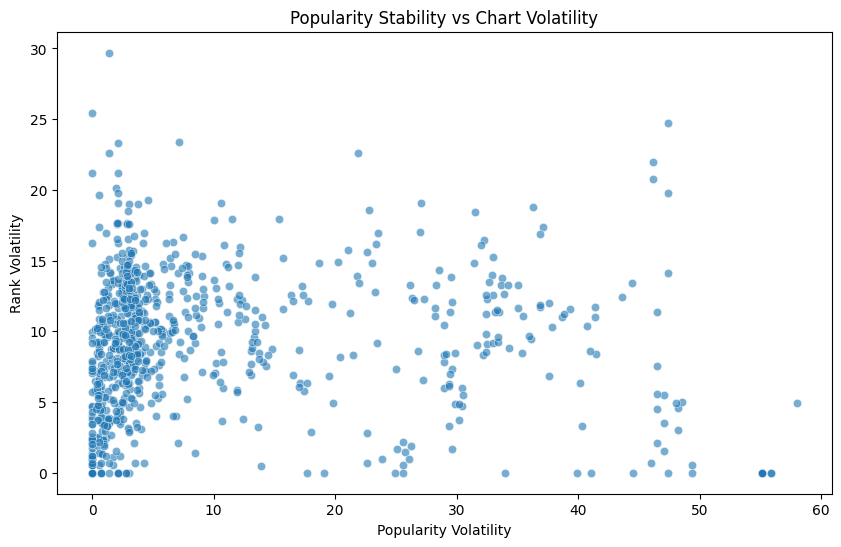

Correlation: 0.16


In [ ]:
# Calculate popularity stability vs rank volatility

popularity_stability = (
    df.groupby(['song', 'artist'])['popularity']
    .std()
    .reset_index(name='popularity_volatility')
)

stability_analysis = song_kpis.merge(
    popularity_stability,
    on=['song', 'artist']
)

stability_analysis['popularity_volatility'] = (
    stability_analysis['popularity_volatility'].fillna(0)
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stability_analysis,
    x='popularity_volatility',
    y='rank_volatility',
    alpha=0.6
)
plt.title('Popularity Stability vs Chart Volatility')
plt.xlabel('Popularity Volatility')
plt.ylabel('Rank Volatility')

plt.show()

stability_corr = stability_analysis[
    'popularity_volatility'
].corr(stability_analysis['rank_volatility'])

print("Correlation:", round(stability_corr, 3))


**Analysis:**

Popularity volatility and rank volatility show a weak positive correlation (r = 0.16), suggesting that changes in popularity have only a limited relationship with chart instability.

# **Content Attribute Analysis**

In [ ]:

# Compare explicit vs non-explicit song performance

explicit_performance = (
    df.groupby('is_explicit')
    .agg(
        average_popularity=('popularity', 'mean'),
        average_rank=('position', 'mean')
    )
    .round(2)
    .reset_index()
)

explicit_performance['content_type'] = explicit_performance[
    'is_explicit'
].map({
    True: 'Explicit',
    False: 'Non-Explicit'
})

print("Explicit vs Non-Explicit Performance:")
explicit_performance[
    ['content_type', 'average_popularity', 'average_rank']
]

Explicit vs Non-Explicit Performance:


,content_type,average_popularity,average_rank
0,Non-Explicit,87.99,25.60
1,Explicit,87.30,25.39


**Analysis:**

Explicit and non-explicit songs show very similar performance, suggesting that explicit content status has little impact on overall playlist rank or popularity.

In [ ]:
# Calculate Explicit Content Share

explicit_share = df['is_explicit'].value_counts(normalize=True) * 100

print("Explicit Content Share:")
print(explicit_share.round(2))

Explicit Content Share:
is_explicit
False    52.06
True     47.94
Name: proportion, dtype: float64


In [ ]:

# Compare single vs album track performance

album_performance = (
    df.groupby('album_type')
    .agg(
        average_popularity=('popularity', 'mean'),
        average_rank=('position', 'mean'),
        unique_songs=('song', 'nunique')
    )
    .round(2)
    .reset_index()
)

print("Single vs Album Performance:")
album_performance

Single vs Album Performance:


,album_type,average_popularity,average_rank,unique_songs
0,album,86.68,26.10,745
1,compilation,78.38,33.19,8
2,single,90.13,23.99,239


**Analysis:**

Singles outperform album and compilation tracks, achieving the highest average popularity (90.13) and the strongest average playlist rank (23.99).

Duration vs Popularity correlation: -0.043
Duration vs Rank correlation: -0.045


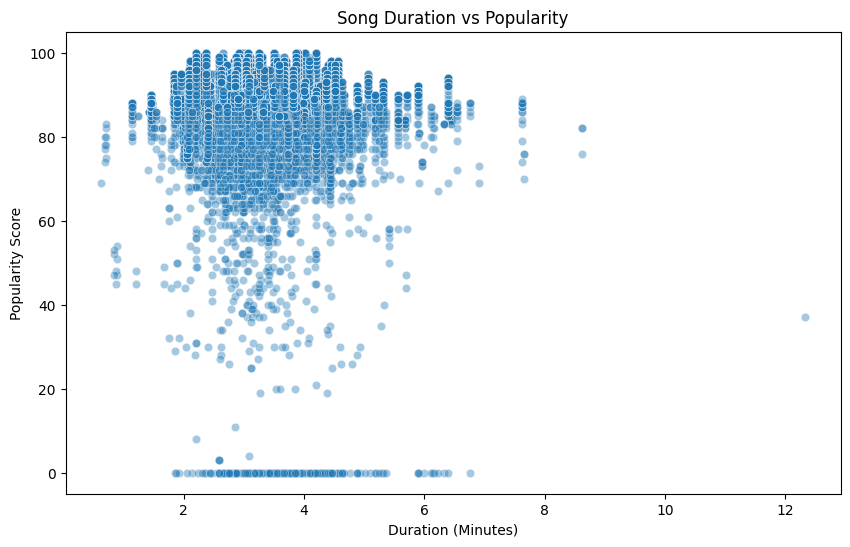

In [ ]:
# Analyze song duration impact

duration_pop_corr = df['duration_min'].corr(df['popularity'])
duration_rank_corr = df['duration_min'].corr(df['position'])

print("Duration vs Popularity correlation:", round(duration_pop_corr, 3))
print("Duration vs Rank correlation:", round(duration_rank_corr, 3))

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='duration_min',
    y='popularity',
    alpha=0.4
)

plt.title('Song Duration vs Popularity')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Popularity Score')

plt.show()

Analysis:

Song duration shows almost no relationship with popularity (r = -0.043) or playlist rank (r = -0.045), suggesting that track length is not an important driver of playlist performance.



Album Size vs Popularity correlation: -0.182
Album Size vs Rank correlation: 0.116


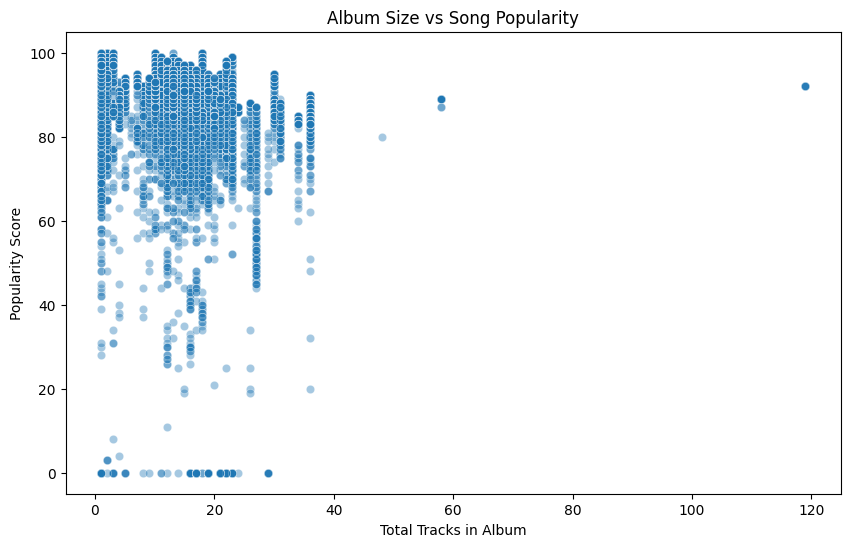

In [ ]:

# Analyze album size vs song success

tracks_pop_corr = df['total_tracks'].corr(df['popularity'])
tracks_rank_corr = df['total_tracks'].corr(df['position'])

print("Album Size vs Popularity correlation:", round(tracks_pop_corr, 3))
print("Album Size vs Rank correlation:", round(tracks_rank_corr, 3))

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='total_tracks',
    y='popularity',
    alpha=0.4
)

plt.title('Album Size vs Song Popularity')
plt.xlabel('Total Tracks in Album')
plt.ylabel('Popularity Score')

plt.show()

**Anslysis:**

Album size shows only a weak relationship with song performance. Larger albums are associated with slightly lower popularity and slightly weaker playlist rankings, but the relationships are not strong.

# **Key Performance Indicators (KPI Summary)**

In [ ]:
# Summary of required project KPIs

print("KEY PERFORMANCE INDICATORS")
print("-" * 45)

print("Average Days on Chart:",
      round(song_kpis['days_on_chart'].mean(), 2))

print("Overall Average Rank:",
      round(song_kpis['average_rank'].mean(), 2))

print("Average Rank Volatility Index:",
      round(song_kpis['rank_volatility'].mean(), 2))

print("Average Popularity Trend Score:",
      round(song_kpis['popularity_trend_score'].mean(), 2))

print("Top Artist Dominance Index:",
      artist_dominance.iloc[0]['artist'],
      "-",
      artist_dominance.iloc[0]['dominance_index'], "%")

print("Explicit Content Share:",
      round(df['is_explicit'].mean() * 100, 2), "%")


KEY PERFORMANCE INDICATORS
---------------------------------------------
Average Days on Chart: 28.4
Overall Average Rank: 30.05
Average Rank Volatility Index: 7.71
Average Popularity Trend Score: 75.66
Top Artist Dominance Index: Taylor Swift - 7.26 %
Explicit Content Share: 47.94 %


In [ ]:

# Save cleaned dataset for Streamlit dashboard

df.to_csv('us_top50_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)

Cleaned dataset saved successfully!
Shape: (27750, 19)
